# Model Loader Sweep Analysis - Tax Dataset

This notebook analyzes the results of the model loader sweep, comparing pre-trained AIM and MST models on the Tax dataset across different epsilon values and repair algorithms.

In [51]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

%matplotlib inline
# Set high DPI for better quality
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style="whitegrid", font_scale=1.1)

In [52]:
def load_results(base_dir="../results"):
    all_data = []
    base_path = Path(base_dir)
    if not base_path.exists():
        base_path = Path("results")
    
    print(f"Searching for results in: {base_path.absolute()}")
    
    count = 0
    for result_dir in base_path.glob("eval_tax_*"):
        for json_file in result_dir.glob("result_*.json"):
            try:
                with open(json_file, "r") as f:
                    data = json.load(f)
                    exp_name = data.get("experiment_name", "")
                    parts = exp_name.split("_")
                    if len(parts) < 5: continue
                        
                    engine = parts[2].upper()
                    epsilon = float(parts[3].replace("eps", ""))
                    repairer = "_".join(parts[4:-1])
                    
                    runtimes = data.get("runtimes", {})
                    tvd_data = data.get("tvd_2way", {})
                    marginal_error = data.get("marginals_error", {})
                    violations = data.get("violations", {})
                    deletion = data.get("deletion_ratio", {})
                    loss_fn = data.get("loss_function", {})
                    
                    row = {
                        "engine": engine,
                        "epsilon": epsilon,
                        "repairer": repairer,
                        "tvd_synthetic": tvd_data.get("synthetic_avg"),
                        "tvd_repaired": tvd_data.get("repaired_avg"),
                        "marginal_error_synthetic": marginal_error.get("synthetic_avg"),
                        "marginal_error_repaired": marginal_error.get("repaired_avg"),
                        "loss_marginal_synthetic": loss_fn.get("synthetic", {}).get("marginal_component"),
                        "loss_marginal_repaired": loss_fn.get("repaired", {}).get("marginal_component"),
                        "violations_synthetic": violations.get("synthetic", 0),
                        "violations_repaired": violations.get("repaired", 0),
                        "deletion_ratio": deletion.get("ratio", 0),
                        "runtime_total": sum(runtimes.values()),
                        "runtime_repairing": runtimes.get("repairing", 0)
                    }
                    all_data.append(row)
                    count += 1
            except Exception as e:
                print(f"Error loading {json_file}: {e}")
                
    print(f"Loaded {count} result files.")
    return pd.DataFrame(all_data)

df = load_results()
if not df.empty:
    df = df.sort_values(["engine", "epsilon", "repairer"])
    df['tvd_increase'] = df['tvd_repaired'] - df['tvd_synthetic']
    df['loss_marginal_increase'] = df['loss_marginal_repaired'] - df['loss_marginal_synthetic']
df.head()

Searching for results in: c:\Users\itayc\OneDrive\Desktop\Master\final\notebooks\..\results
Loaded 49 result files.


,engine,epsilon,repairer,tvd_synthetic,tvd_repaired,marginal_error_synthetic,marginal_error_repaired,loss_marginal_synthetic,loss_marginal_repaired,violations_synthetic,violations_repaired,deletion_ratio,runtime_total,runtime_repairing,tvd_increase,loss_marginal_increase
0,AIM,0.2,vanilla_vc,0.018276,0.080381,0.073330,0.155931,0.002244,0.018025,3100885,0,0.23014,1335.474969,1325.959570,0.062105,0.015781
1,AIM,0.3,classic_vc,0.013382,0.112953,0.047526,0.449975,0.001211,0.026415,2415510,0,0.30704,1755.485578,1747.839173,0.099571,0.025204
2,AIM,0.3,vanilla_vc,0.013382,0.073751,0.047526,0.253643,0.001211,0.016187,2415510,0,0.20236,1053.061922,1045.829225,0.060369,0.014976
3,AIM,0.3,weighted_vc,0.013382,0.116811,0.047526,0.297735,0.001211,0.018913,2415510,0,0.32048,2914.590727,2904.915245,0.103429,0.017702
4,AIM,0.4,classic_vc,0.012450,0.112625,0.016630,0.254002,0.001566,0.021309,2234727,0,0.29136,1131.489886,1123.746476,0.100175,0.019743


## Utility Cost Split by Generation System

We analyze the increase in TVD and Marginal Loss for each engine separately to compare how different repair algorithms affect them.

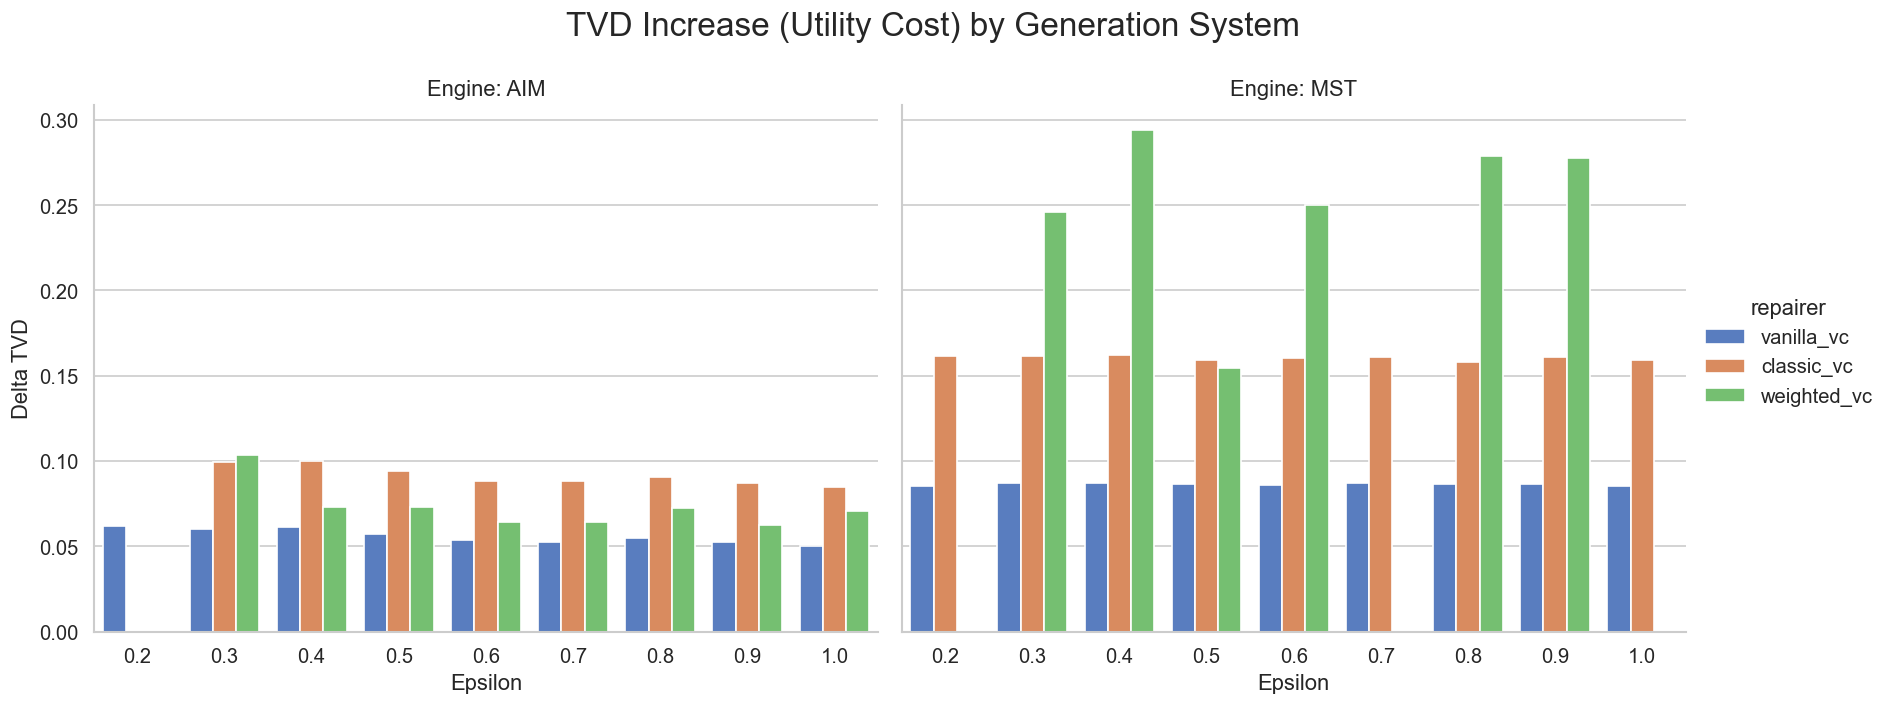

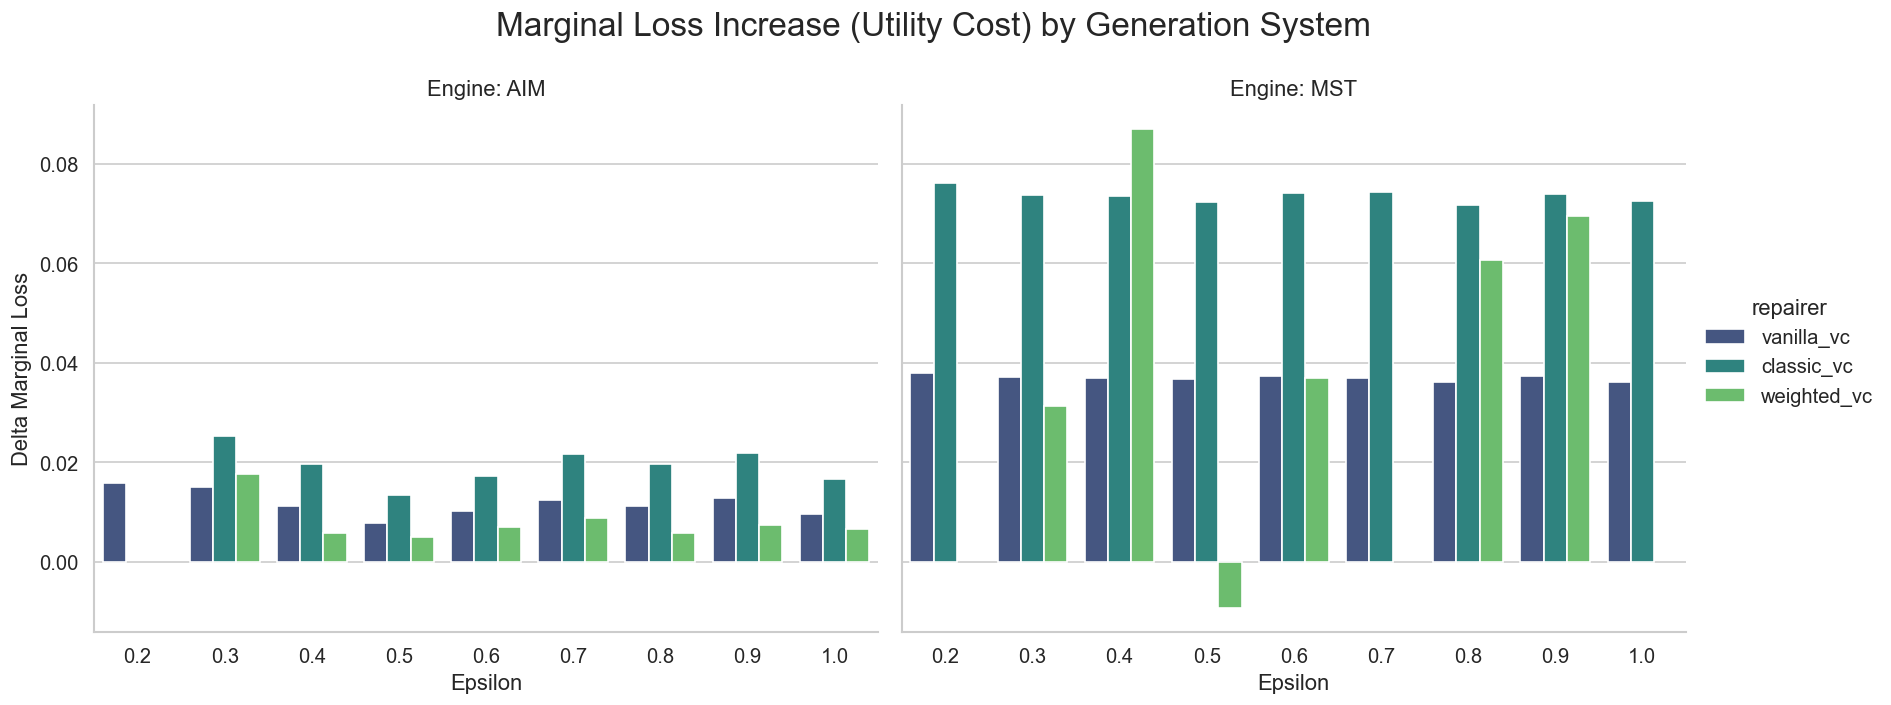

In [53]:
if not df.empty:
    # TVD Increase Split by Engine
    g = sns.catplot(
        data=df[df['epsilon'] >= 0.2], 
        x="epsilon", y="tvd_increase", hue="repairer", col="engine",
        kind="bar", height=6, aspect=1.2, palette="muted"
    )
    g.fig.subplots_adjust(top=0.85)
    g.fig.suptitle("TVD Increase (Utility Cost) by Generation System", fontsize=20)
    g.set_axis_labels("Epsilon", "Delta TVD")
    g.set_titles("Engine: {col_name}")
    plt.show()

    # Marginal Loss Increase Split by Engine
    g = sns.catplot(
        data=df[df['epsilon'] >= 0.2], 
        x="epsilon", y="loss_marginal_increase", hue="repairer", col="engine",
        kind="bar", height=6, aspect=1.2, palette="viridis"
    )
    g.fig.subplots_adjust(top=0.85)
    g.fig.suptitle("Marginal Loss Increase (Utility Cost) by Generation System", fontsize=20)
    g.set_axis_labels("Epsilon", "Delta Marginal Loss")
    g.set_titles("Engine: {col_name}")
    plt.show()

## Data Utility Trends: TVD vs. Epsilon

A broader look at TVD trends before and after the repair process.

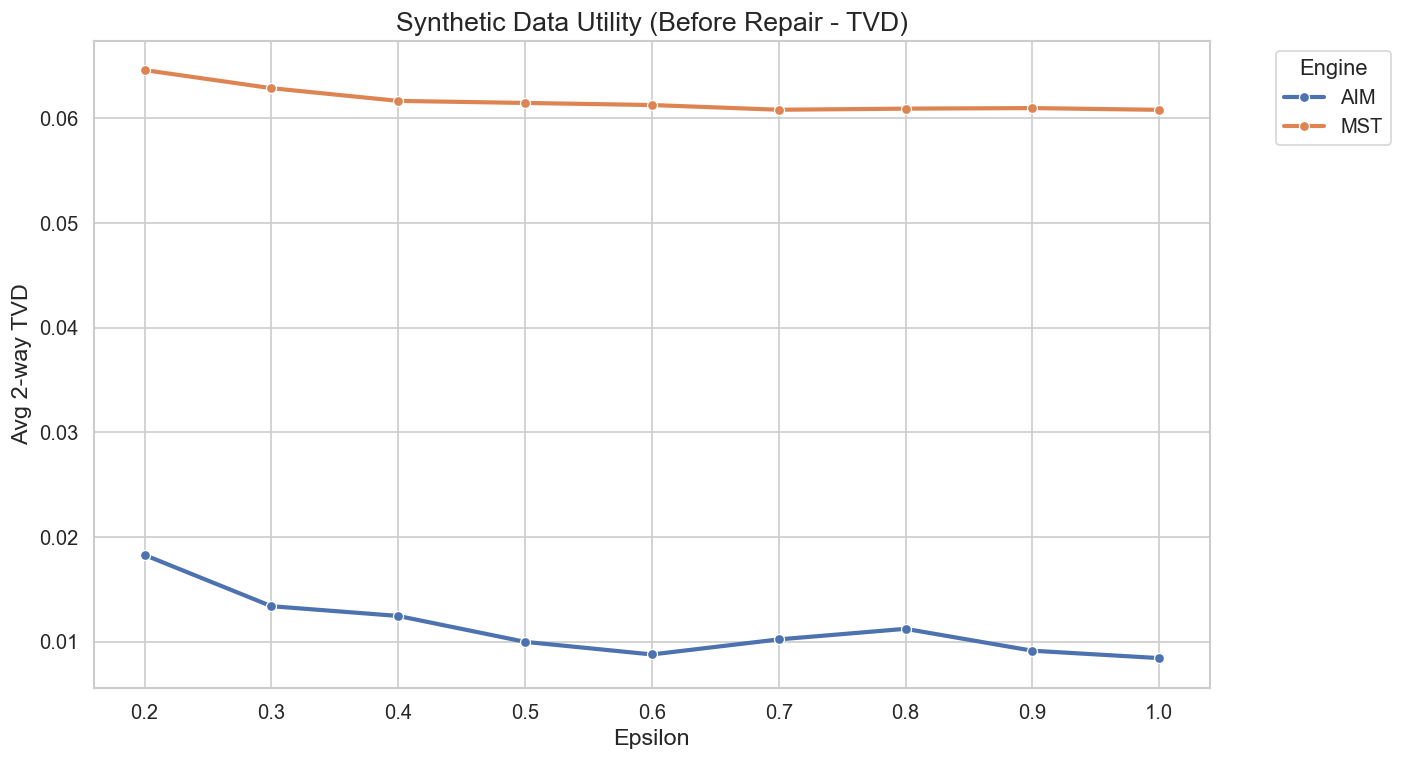

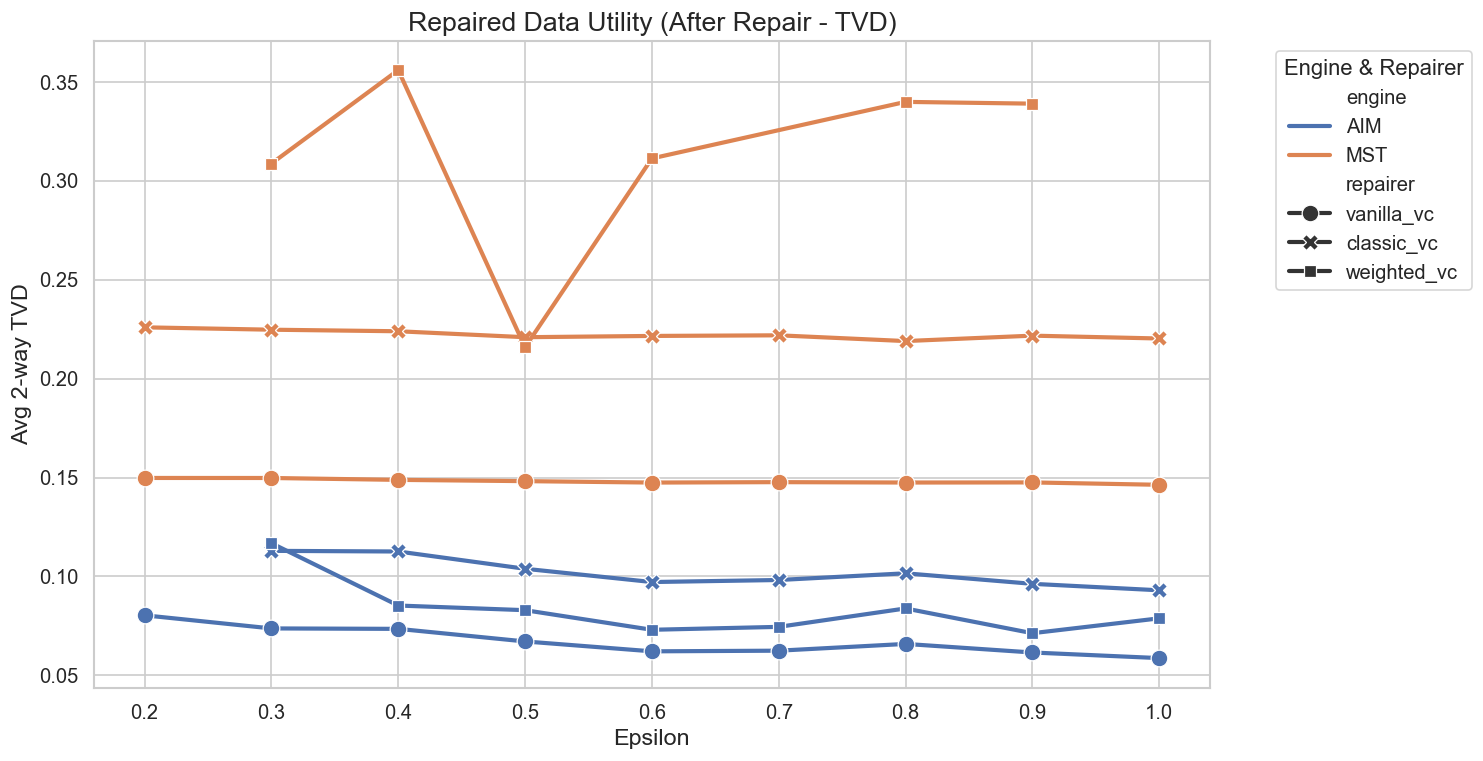

In [54]:
if not df.empty:
    plt.figure(figsize=(12, 7))
    sns.lineplot(data=df, x="epsilon", y="tvd_synthetic", hue="engine", marker='o', linewidth=2.5)
    plt.title("Synthetic Data Utility (Before Repair - TVD)", fontsize=16)
    plt.ylabel("Avg 2-way TVD", fontsize=14)
    plt.xlabel("Epsilon", fontsize=14)
    plt.legend(title="Engine", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

    plt.figure(figsize=(12, 7))
    sns.lineplot(data=df, x="epsilon", y="tvd_repaired", hue="engine", style="repairer", 
                 markers=True, dashes=False, linewidth=2.5, markersize=10)
    plt.title("Repaired Data Utility (After Repair - TVD)", fontsize=16)
    plt.ylabel("Avg 2-way TVD", fontsize=14)
    plt.xlabel("Epsilon", fontsize=14)
    plt.legend(title="Engine & Repairer", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

## Constraint Satisfaction & Record Loss

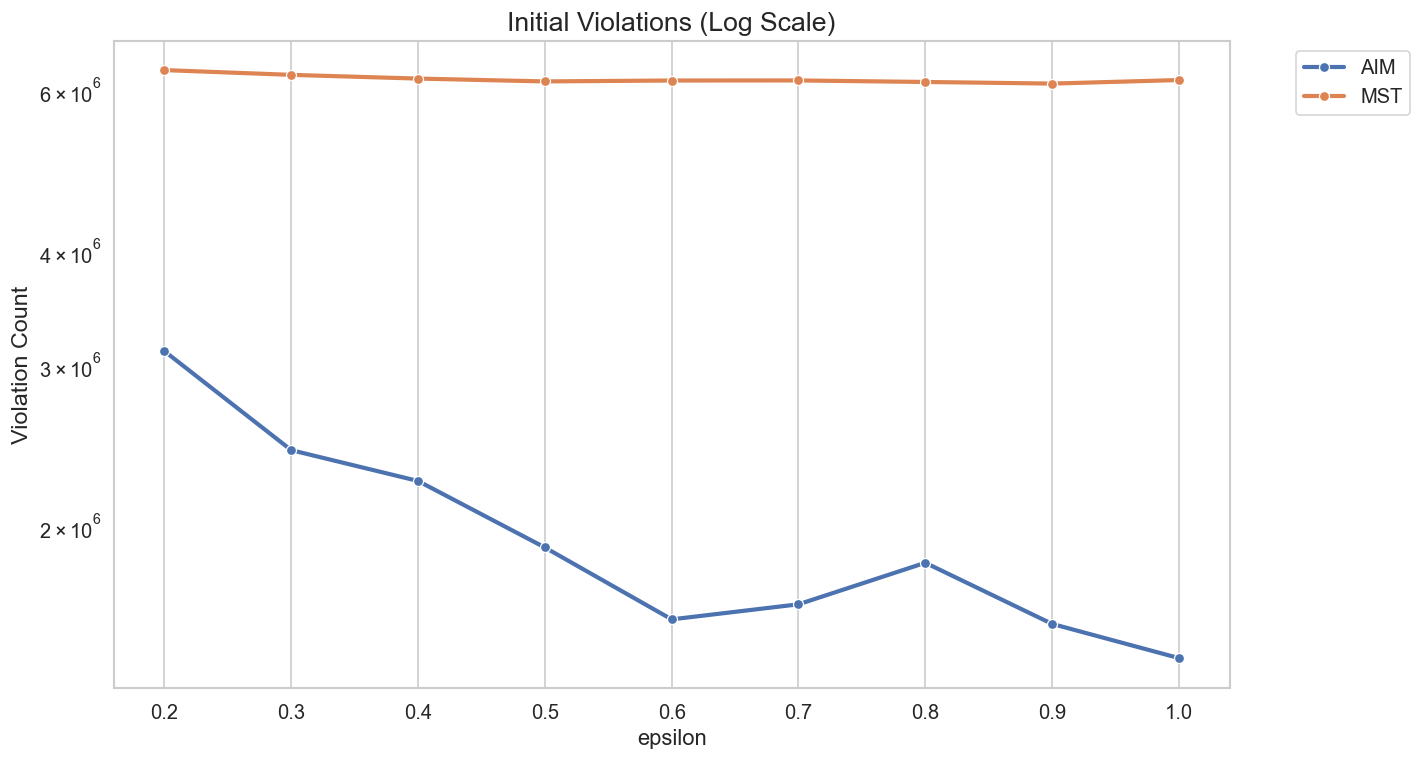

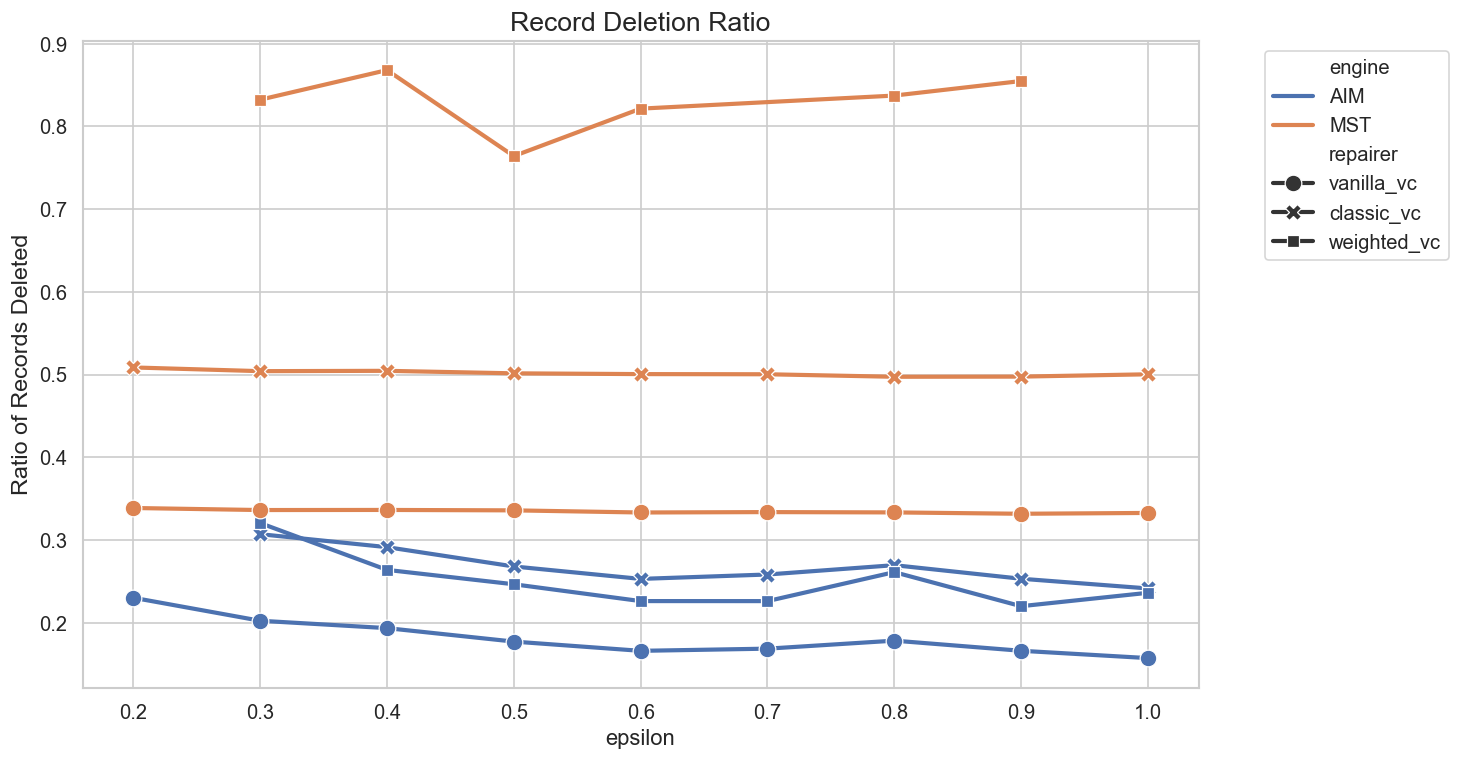

In [55]:
if not df.empty:
    plt.figure(figsize=(12, 7))
    sns.lineplot(data=df, x="epsilon", y="violations_synthetic", hue="engine", marker='o', linewidth=2.5)
    plt.yscale("log")
    plt.title("Initial Violations (Log Scale)", fontsize=16)
    plt.ylabel("Violation Count", fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

    plt.figure(figsize=(12, 7))
    sns.lineplot(data=df, x="epsilon", y="deletion_ratio", hue="engine", style="repairer", 
                 markers=True, dashes=False, linewidth=2.5, markersize=10)
    plt.title("Record Deletion Ratio", fontsize=16)
    plt.ylabel("Ratio of Records Deleted", fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

## Efficiency Analysis

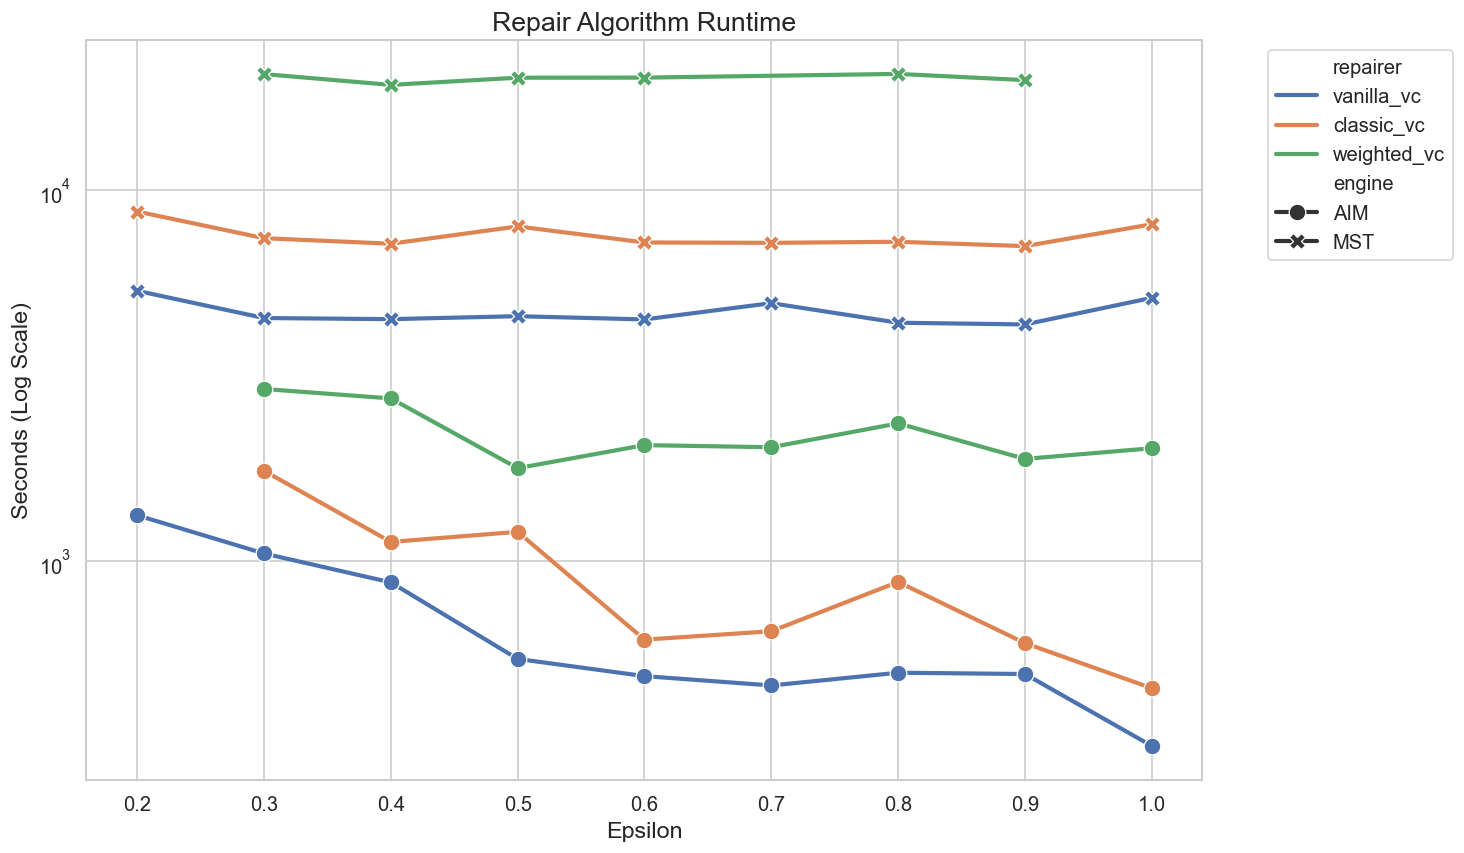

In [56]:
if not df.empty:
    plt.figure(figsize=(12, 8))
    sns.lineplot(data=df, x="epsilon", y="runtime_repairing", hue="repairer", style="engine", 
                 markers=True, dashes=False, linewidth=2.5, markersize=10)
    plt.yscale("log")
    plt.title("Repair Algorithm Runtime", fontsize=16)
    plt.ylabel("Seconds (Log Scale)", fontsize=14)
    plt.xlabel("Epsilon", fontsize=14)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()